# 信息的价值：用偷窥突破视野受限

## 介绍

## 知识点


## 环境版本

In [1]:
from util import show_version

show_version()

+------+----------------------------------------------------------------------------------------+
| Info |                                   《动手学人工智能》                                   |
+------+----------------------------------------------------------------------------------------+
| 作者 |                                       吾辈亦有感                                       |
| 哔站 |                      https://space.bilibili.com/3461565265217538                       |
| 定位 |      基于'从零构建'的理念，用实战降低学习大模型的门槛，帮助程序员快速入门大模型。      |
| 愿景 | 若我的经验能让你的AI学习之路走的更容易一点，让你的生活变得更美好，我将倍感荣幸！祝好😄 |
+------+----------------------------------------------------------------------------------------+

环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 观察数据

In [2]:
# 打开文件并读取前5行
from util import show_first_n_lines

show_first_n_lines('../dataset/addition.txt', 5)

,行数,内容
0,1,16+75=91
1,2,52+607=659
2,3,75+22=97
3,4,63+22=85
4,5,795+3=798


## 自定义分词器

In [3]:
from util import print_table
import torch


class SimpleTokenizer:
    def __init__(self, vocab, pad_token="<|pad|>", unk_token="<|unk|>", bos_token="<|bos|>", eos_token="<|eos|>"):
        """
        初始化简单分词器
        """

        self.vocab = vocab

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 特殊token
        self.pad_token = pad_token
        self.pad_token_id = self.vocab[pad_token]

        self.unk_token = unk_token
        self.unk_token_id = self.vocab[unk_token]

        self.bos_token = bos_token
        self.bos_token_id = self.vocab[bos_token]

        self.eos_token = eos_token
        self.eos_token_id = self.vocab[eos_token]

        self.special_tokens = [self.pad_token, self.unk_token, self.bos_token, self.eos_token]

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def encode(self, text):
        # 将文本拆分为单个字符和特殊标记
        tokens = self._tokenize_special_tokens(text)

        # 将每个token转换为对应的token ID
        input_ids = [self.vocab[token] for token in tokens if token in self.vocab]

        return input_ids

    def _tokenize_special_tokens(self, text):
        # 识别并处理特殊标记
        tokens = []
        i = 0
        while i < len(text):
            # 检查是否匹配特殊标记
            for token in self.special_tokens:
                if text[i:i + len(token)] == token:
                    tokens.append(token)
                    i += len(token)
                    break
            else:
                # 如果不是特殊标记，则逐个字符处理
                tokens.append(text[i])
                i += 1
        return tokens

    def decode(self, input_ids, skip_special_tokens=True):
        # 如果 input_ids 是 torch.Tensor，则转换为列表
        if isinstance(input_ids, torch.Tensor):
            input_ids = input_ids.squeeze().tolist()

        # 将token ID序列转换为对应的字符
        tokens = [self.ids_to_tokens.get(id) for id in input_ids]

        # 去除开始符和结束符
        if skip_special_tokens:
            tokens = [token for token in tokens if token not in self.special_tokens]
        return ''.join(tokens)

    def __call__(self, texts, max_length=None, padding=False, return_tensors=False):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        all_attention_masks = []

        for text in texts:
            token_ids = self.encode(text)

            # 处理填充和注意力掩码
            if padding and max_length is not None:
                attention_mask = [1] * len(token_ids) + [0] * (max_length - len(token_ids))
                token_ids += [self.pad_token_id] * (max_length - len(token_ids))
            else:
                attention_mask = [1] * len(token_ids)

            all_token_ids.append(token_ids)
            all_attention_masks.append(attention_mask)

        if is_single_text:
            all_token_ids = all_token_ids[0]
            all_attention_masks = all_attention_masks[0]

        # 转换为tensor
        if return_tensors:
            all_token_ids = torch.tensor(all_token_ids, dtype=torch.long)
            all_attention_masks = torch.tensor(all_attention_masks, dtype=torch.long)

        return {'input_ids': all_token_ids, 'attention_mask': all_attention_masks}

    def info(self):
        """
        打印分词器的详细信息
        """

        # 通用信息表
        info_data = [
            ["Vocabulary Size", self.vocab_size],
            ["Padding Token", f"{self.pad_token} (ID: {self.pad_token_id})"],
            ["Unknown Token", f"{self.unk_token} (ID: {self.unk_token_id})"],
            ["Start Token", f"{self.bos_token} (ID: {self.bos_token_id})"],
            ["End Token", f"{self.eos_token} (ID: {self.eos_token_id})"]
        ]

        print_table("General Information", field_names=["Information", "Value"], data=info_data)

        # 字符到ID的映射表
        print_table("Token Mapping", field_names=["Token", "ID"], data=[
            [char, char_id] for char, char_id in self.vocab.items()
        ])

        # 编码解码示例表
        example = "52+607 "  # 示例输入
        print_table("Encoding and Decoding Example", field_names=["Input", "Encode", "Decode"], data=[
            [example, self.encode(example), self.decode(self.encode(example))],
        ])

In [4]:
vocab = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "+": 10,
    "=": 11,
    "<|pad|>": 12,
    "<|unk|>": 13,
    "<|bos|>": 14,
    "<|eos|>": 15
}

tokenizer = SimpleTokenizer(vocab)

# 初始化分词器
tokenizer.info()  # 打印分词器信息


General Information：
+-----------------+------------------+
|   Information   |      Value       |
+-----------------+------------------+
| Vocabulary Size |        16        |
|  Padding Token  | <|pad|> (ID: 12) |
|  Unknown Token  | <|unk|> (ID: 13) |
|   Start Token   | <|bos|> (ID: 14) |
|    End Token    | <|eos|> (ID: 15) |
+-----------------+------------------+

Token Mapping：
+---------+----+
|  Token  | ID |
+---------+----+
|    0    | 0  |
|    1    | 1  |
|    2    | 2  |
|    3    | 3  |
|    4    | 4  |
|    5    | 5  |
|    6    | 6  |
|    7    | 7  |
|    8    | 8  |
|    9    | 9  |
|    +    | 10 |
|    =    | 11 |
| <|pad|> | 12 |
| <|unk|> | 13 |
| <|bos|> | 14 |
| <|eos|> | 15 |
+---------+----+

Encoding and Decoding Example：
+---------+---------------------+--------+
|  Input  |        Encode       | Decode |
+---------+---------------------+--------+
| 52+607  | [5, 2, 10, 6, 0, 7] | 52+607 |
+---------+---------------------+--------+


## 数据转换

In [5]:
class TextTransform:
    def __init__(self, tokenizer: SimpleTokenizer, max_length=20, is_reverse=False):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.is_reverse = is_reverse

    def __call__(self, text):
        if self.is_reverse:
            encoded = self.tokenizer(text, max_length=self.max_length, padding=True, return_tensors=True)
            
            encoder_input_ids = encoded['input_ids']
            encoder_pad_mask = encoded['attention_mask']

            # 输入反转，注意：torch.flip 会创建新的张量，不会修改原张量
            encoder_input_ids = torch.flip(encoder_input_ids, dims=[-1])
            encoder_pad_mask = torch.flip(encoder_pad_mask, dims=[-1])
            
            return {
                "input_ids": encoder_input_ids,
                "attention_mask": encoder_pad_mask,
            }
        
            
        else:
            return self.tokenizer(text, max_length=self.max_length, padding=True, return_tensors=True)

## 构造数据集

In [6]:
from torch.utils.data import Dataset


class TextGenerationDataset(Dataset):
    def __init__(self, questions, answers, encoder_transform: TextTransform,
                 decoder_transform: TextTransform):
        self.questions = questions
        self.answers = answers
        self.encoder_transform = encoder_transform
        self.decoder_transform = decoder_transform

    def __len__(self):
        return len(self.questions)
    
    def __getitem__(self, idx):
        question = self.questions[idx]
        answer = self.answers[idx]
    
        question_encoded = self.encoder_transform(question)
        encoder_input_ids = question_encoded["input_ids"]
        encoder_pad_mask = question_encoded["attention_mask"]
    
        answer_encoded = self.decoder_transform(answer)
        answer_ids = answer_encoded["input_ids"]
        answer_pad_mask = answer_encoded["attention_mask"]
    
        return {
            "question": question,
            "answer": answer,
            'encoder_input_ids': encoder_input_ids,
            'encoder_pad_mask': encoder_pad_mask,
            'decoder_target_ids': answer_ids,
            'decoder_pad_mask': answer_pad_mask
        }


    @classmethod
    def from_file(cls, file_path, encoder_transform: TextTransform, decoder_transform: TextTransform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        questions = []
        answers = []

        # 读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip() == '':  # 跳过空行
                    continue
                try:
                    # 查找等号的位置，将行分割为问题和答案
                    idx = line.find('=')
                    # 将样本添加到列表中: (question, answer)，answer中去掉"="以及最后的"\n"
                    question = line[:idx]
                    answer = line[idx + 1:].strip()
                    questions.append(question)
                    answers.append(answer)
                except Exception as e:
                    # 如果处理某行时出错，打印错误信息并跳过
                    print(f"Error processing line: {line}")
                    print(f"Error message: {e}")
                    continue

        # 创建数据集实例
        return cls(questions, answers, encoder_transform, decoder_transform)

In [7]:
from pprint import pprint

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab)

# 2️⃣ 初始化数据转换
encoder_transform = TextTransform(tokenizer, max_length=7, is_reverse=True)
decoder_transform = TextTransform(tokenizer, max_length=4)

# 3️⃣ 加载数据集
file_path = "../dataset/addition.txt"
dataset = TextGenerationDataset.from_file(file_path, encoder_transform=encoder_transform, decoder_transform=decoder_transform)

pprint(dataset[0], sort_dicts=False)

{'question': '16+75',
 'answer': '91',
 'encoder_input_ids': tensor([12, 12,  5,  7, 10,  6,  1]),
 'encoder_pad_mask': tensor([0, 0, 1, 1, 1, 1, 1]),
 'decoder_target_ids': tensor([ 9,  1, 12, 12]),
 'decoder_pad_mask': tensor([1, 1, 0, 0])}


## 初始化数据模组

In [8]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size, encoder_transform: TextTransform, decoder_transform: TextTransform, train_data_file, val_data_file="", test_data_file=""):
        super().__init__()

        self.batch_size = batch_size
        self.encoder_transform = encoder_transform
        self.decoder_transform = decoder_transform
        
        
        self.train_data_file = train_data_file
        self.val_data_file = val_data_file
        self.test_data_file = test_data_file

        self.test_dataset = None
        self.val_dataset = None
        self.train_dataset = None

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        pass

    def setup(self, stage=None):
        # 加载训练数据集
        self.train_dataset = TextGenerationDataset.from_file(self.train_data_file, encoder_transform=self.encoder_transform, decoder_transform=self.decoder_transform)

        # 加载验证数据集
        if self.val_data_file == "":
            self.val_dataset = self.train_dataset
        else:
            self.val_dataset = TextGenerationDataset.from_file(self.val_data_file, encoder_transform=self.encoder_transform, decoder_transform=self.decoder_transform)

        # 加载测试数据集
        if self.test_data_file == "":
            self.test_dataset = self.train_dataset
        else:
            self.test_dataset = TextGenerationDataset.from_file(self.test_data_file, encoder_transform=self.encoder_transform, decoder_transform=self.decoder_transform)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

In [9]:
from pprint import pprint

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab)

# 2️⃣ 初始化数据转换
encoder_transform = TextTransform(tokenizer, max_length=7, is_reverse=True)
decoder_transform = TextTransform(tokenizer, max_length=4)

# 3️⃣ 加载数据模组
file_path = "../dataset/addition.txt"
text_datamodule = TextDataModule(batch_size=2, encoder_transform=encoder_transform, decoder_transform=decoder_transform, train_data_file=file_path)

# 调用 setup 方法初始化数据集
text_datamodule.setup()

# 打印一个批次的数据
print("打印一个批次的数据：")
for batch in text_datamodule.train_dataloader():
    pprint(batch, sort_dicts=False)
    break

打印一个批次的数据：
{'question': ['606+385', '35+94'],
 'answer': ['991', '129'],
 'encoder_input_ids': tensor([[ 5,  8,  3, 10,  6,  0,  6],
        [12, 12,  4,  9, 10,  5,  3]]),
 'encoder_pad_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1, 1]]),
 'decoder_target_ids': tensor([[ 9,  9,  1, 12],
        [ 1,  2,  9, 12]]),
 'decoder_pad_mask': tensor([[1, 1, 1, 0],
        [1, 1, 1, 0]])}


## 构建模型

In [10]:
import torch


class Encoder(torch.nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super(Encoder, self).__init__()

        # 词嵌入层
        self.embedding = torch.nn.Embedding(vocab_size, embed_dim)

        # GRU编码器
        self.gru = torch.nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, input_ids):
        """
        前向传播
        
        参数:
            input_ids (Tensor): 输入序列的token IDs, shape: [batch_size, seq_len]
            
        返回:
            outputs (Tensor): 编码器所有时间步的输出, shape: [batch_size, seq_len, hidden_dim]
            hidden (Tensor): 编码器最后时间步的隐藏状态, shape: [num_layers, batch_size, hidden_dim]
        """
        embedded = self.embedding(input_ids)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

In [11]:
class PeekDecoder(torch.nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super(PeekDecoder, self).__init__()

        # 词嵌入层
        self.embedding = torch.nn.Embedding(vocab_size, embed_dim)

        # GRU解码器
        self.gru = torch.nn.GRU(
            input_size=embed_dim + hidden_dim, # GRU层：输入维度为hidden_dim + hidden_dim（🌟改进点🌟）
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        # 输出层：输入维度为hidden_dim + hidden_dim（🌟改进点🌟）
        self.output_projection = torch.nn.Linear(embed_dim + hidden_dim, vocab_size) 

    def forward(self, input_ids, encoder_hidden, encoder_output):
        """
        前向传播 (用于训练，Teacher Forcing)
    
        参数:
            input_ids (Tensor): 目标序列的 token IDs, shape: [batch_size, tgt_seq_len]
            encoder_hidden (Tensor): 编码器最后时间步的隐藏状态, shape: [num_layers, batch_size, hidden_dim]
                                   这通常作为解码器初始隐藏状态。
            encoder_output (Tensor): 编码器所有时间步的输出, shape: [batch_size, src_seq_len, hidden_dim]
                                    用于提供全局上下文 ("peek")。
    
        返回:
            output_logits (Tensor): 每个时间步的词汇表分布, shape: [batch_size, tgt_seq_len, vocab_size]
            decoder_hidden (Tensor): 解码器最后时间步的隐藏状态, shape: [num_layers, batch_size, hidden_dim]
        """
        batch_size, tgt_seq_len = input_ids.size()
        # 使用编码器最后的隐藏状态初始化解码器隐藏状态
        decoder_hidden = encoder_hidden
    
        outputs = []
    
        # 循环遍历目标序列的每个时间步 (除了最后一个，因为没有下一个输入)
        for t in range(tgt_seq_len):
            # 取出当前时间步的输入 token ID
            input_id = input_ids[:, t:t+1] # Shape: [batch_size, 1]
    
            # 调用 forward_step 处理单步
            # 注意：我们需要将 encoder_output 传递给 forward_step，
            # 或者在 forward_step 内部能够访问到它。
            # 这里我们假设 forward_step 被修改为接受 encoder_output
            output_logits_step, decoder_hidden = self.forward_step(input_id, decoder_hidden, encoder_output)
    
            # 收集每一步的输出 logits (去掉序列长度维度 1)
            outputs.append(output_logits_step.squeeze(1)) # Shape: [batch_size, vocab_size]
    
        # 将所有时间步的输出堆叠起来
        # outputs list contains tensors of [batch_size, vocab_size]
        # After stack: [tgt_seq_len, batch_size, vocab_size]
        # Transpose to: [batch_size, tgt_seq_len, vocab_size]
        output_logits = torch.stack(outputs, dim=1)
    
        return output_logits, decoder_hidden
        

    def forward_step(self, input_id, decoder_hidden, encoder_output):
        """
        单步解码：
        - 输入：当前时间步的输入和隐藏状态
        - 输出：当前时间步的输出和新的隐藏状态
        """
        token_embed = self.embedding(input_id)  # [batch_size, 1, embed_dim]

        # 获取编码器最后一层的最后一个时间步的输出作为上下文向量
        final_encoder_output = encoder_output[:, -1:, :]  # [batch_size, 1, hidden_dim]

        #  拼接编码器最终输出和词嵌入，作为 GRU 层的输入（🌟改进点🌟）
        gru_input = torch.cat((token_embed, final_encoder_output), dim=-1)  

        output, decoder_hidden = self.gru(gru_input, decoder_hidden)

        # 拼接编码器最终输出和GRU输出，作为输出层的输入（🌟改进点🌟）
        output_with_context = torch.cat((output, final_encoder_output), dim=-1)  # [batch_size, 1, hidden_dim + hidden_dim]
        output_logits = self.output_projection(output_with_context)
        return output_logits, decoder_hidden

In [12]:
class SequenceGenerator(L.LightningModule):
    def __init__(self, tokenizer: SimpleTokenizer, embed_dim, hidden_dim, num_layers=1, learning_rate=1e-3, generate_max_length=4):
        super().__init__()
    
        # 实例化编码器和解码器
        self.encoder = Encoder(tokenizer.vocab_size, embed_dim, hidden_dim, num_layers)
        self.decoder = PeekDecoder(tokenizer.vocab_size, embed_dim, hidden_dim, num_layers)
    
        self.tokenizer = tokenizer
        self.learning_rate = learning_rate
        self.generate_max_length = generate_max_length  # 添加最大长度属性
    
        # 用于存储训练和验证过程中的指标
        self.train_step_losses = []
        self.train_epoch_losses = []
        self.validation_step_outputs = []
        self.validation_epoch_outputs = []
    
        # 示例输入
        self.example_input_array = (
            torch.randint(0, tokenizer.vocab_size, (32, 10), dtype=torch.long),
            torch.randint(0, tokenizer.vocab_size, (32, 5), dtype=torch.long)
        )


    def forward(self, input_ids, target_ids=None):
        """前向传播"""
        batch_size = input_ids.size(0)

        # 1. 编码阶段：提取输入序列特征
        encoder_outputs, encoder_hidden = self.encoder(input_ids)

        # 2. 解码阶段：生成输出序列
        if target_ids is not None:
            # 训练阶段：使用真实目标序列作为输入（teacher forcing）
            return self._decode_with_targets(encoder_outputs, encoder_hidden, target_ids, self.generate_max_length)
        else:
            # 推理阶段：自回归生成序列
            return self._decode_autoregressive(encoder_outputs, encoder_hidden, batch_size, self.generate_max_length)

    def _decode_with_targets(self, encoder_outputs, encoder_hidden, target_ids, generate_max_length):
        """
        训练阶段解码：使用teacher forcing
        """
        batch_size = encoder_outputs.size(0)

        # 初始化解码器输入为起始标记（这里假设用空格作为起始符，ID为12）
        decoder_input = torch.full((batch_size, 1), self.tokenizer.bos_token_id, device=encoder_outputs.device, dtype=torch.long)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        # 使用目标序列作为输入，逐步解码
        for i in range(generate_max_length):
            decoder_output, decoder_hidden = self.decoder.forward_step(decoder_input, decoder_hidden, encoder_outputs)
            decoder_outputs.append(decoder_output)

            # 使用真实目标作为下一步输入
            decoder_input = target_ids[:, i].unsqueeze(1)

        # 拼接所有时间步的输出
        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        return torch.nn.functional.log_softmax(decoder_outputs, dim=-1)

    def _decode_autoregressive(self, encoder_outputs, encoder_hidden, batch_size, generate_max_length):
        """
        推理阶段解码：自回归生成
        """
        # 初始化解码器输入为起始标记
        decoder_input = torch.full((batch_size, 1), self.tokenizer.bos_token_id,
                                   device=encoder_outputs.device, dtype=torch.long)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(generate_max_length):
            # 单步解码
            decoder_output, decoder_hidden = self.decoder.forward_step(decoder_input, decoder_hidden, encoder_outputs)
            decoder_outputs.append(decoder_output)

            # 使用模型预测作为下一步输入
            _, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze(-1).detach()

        # 拼接所有时间步的输出
        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        return torch.nn.functional.log_softmax(decoder_outputs, dim=-1)

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["encoder_input_ids"]
        target_ids = batch["decoder_target_ids"]

        # 前向传播
        outputs = self(input_ids, target_ids)  # 训练时传入target_ids

        # 计算损失 - 需要调整维度以适应交叉熵损失
        # outputs: [batch_size, seq_len, vocab_size]
        # target_ids: [batch_size, seq_len]
        loss = torch.nn.functional.cross_entropy(
            outputs.view(-1, outputs.size(-1)),
            target_ids.view(-1)
        )

        """
        对于序列生成任务，通常我们会采用以下几种方式来计算准确率：
            1. 序列级别准确率：整个生成序列完全匹配目标序列才算正确
            2. token级别准确率：计算所有token中预测正确的比例
            3. BLEU/ROUGE等评价指标：更复杂的文本生成评价指标
        """
        # 计算token级别的准确率
        preds = torch.argmax(outputs, dim=-1)
        mask = (target_ids != self.tokenizer.pad_token_id)  # 忽略填充位置
        correct_tokens = ((preds == target_ids) & mask).sum().float()
        total_tokens = mask.sum().float()
        token_acc = correct_tokens / total_tokens

        # 计算序列级别的准确率
        # 对于每个序列，只有当所有非填充位置都预测正确才算正确
        seq_correct = ((preds == target_ids) | ~mask).all(dim=1).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_token_acc', token_acc)
        self.log('train_seq_acc', seq_correct)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def validation_step(self, batch, batch_idx):
        """验证步骤"""

        input_ids = batch["encoder_input_ids"]
        target_ids = batch["decoder_target_ids"]

        # 前向传播
        outputs = self(input_ids)

        # 计算预测值
        preds = torch.argmax(outputs, dim=-1)

        # 创建掩码以忽略填充值
        mask = (target_ids != self.tokenizer.pad_token_id)

        # 计算token级别的准确率
        correct_tokens = ((preds == target_ids) & mask).sum().float()
        total_tokens = mask.sum().float()
        token_acc = correct_tokens / total_tokens if total_tokens > 0 else torch.tensor(0.0)

        # 计算序列级别的准确率
        seq_correct = ((preds == target_ids) | ~mask).all(dim=1).float().mean()

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({
            'preds': preds,
            'target_ids': target_ids,
            'token_acc': token_acc,
            'seq_acc': seq_correct
        })
        
        if batch_idx % 500 == 0:
            print(f"Validation Step {batch_idx}: Token Accuracy={token_acc.item():.4f}, Seq Accuracy={seq_correct.item():.4f}")

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_target_ids = torch.cat([x['target_ids'] for x in self.validation_step_outputs])
    
        # 1. 计算序列（样本）级别的准确率
        # 创建掩码以标识非填充位置
        mask = (all_target_ids != self.tokenizer.pad_token_id)
        # 计算每个序列是否完全正确（所有非填充位置都预测正确）
        seq_correct = ((all_preds == all_target_ids) | ~mask).all(dim=1)
        # 序列总数
        total_sequences = all_preds.size(0)
        # 正确预测的序列数
        correct_sequences = seq_correct.sum().item()
        # 序列级别准确率
        seq_acc = correct_sequences / total_sequences if total_sequences > 0 else 0.0
    
        # 2. 计算 Token 级别的准确率
        # 计算所有非填充位置的预测总数
        total_tokens = mask.sum().item()
        # 计算所有非填充位置预测正确的总数
        correct_tokens = ((all_preds == all_target_ids) & mask).sum().item()
        # Token 级别准确率
        token_acc = correct_tokens / total_tokens if total_tokens > 0 else 0.0
    
        # 3. 将评估结果保存到 validation_epoch_outputs 列表中
        self.validation_epoch_outputs.append({
            "epoch": self.current_epoch,
            "总样本数": total_sequences,
            "正确样本数": correct_sequences,
            "样本准确率": round(seq_acc, 4),
            "总Token数": total_tokens,
            "正确Token数": correct_tokens,
            "Token准确率": round(token_acc, 4)
        })
        
        # 记录日志
        self.log('总样本数', total_sequences)
        self.log('正确样本数', correct_sequences)
        self.log('样本准确率', seq_acc)
        self.log('总Token数', total_tokens)
        self.log('正确Token数', correct_tokens)
        self.log('Token准确率', token_acc)
    
        # 清空缓存
        self.validation_step_outputs.clear()
    


    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.validation_epoch_outputs.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer
    
    def generate(self, input_ids):
        """
        根据输入序列生成输出序列文本
        
        参数:
            input_ids (Tensor): 输入序列的token IDs, shape: [batch_size, seq_len]
            
        返回:
            generated_texts (list): 生成的文本列表
        """
        # 1. 调用模型的 forward 方法 (推理模式，无 target_ids) 生成 logits
        generated_logits = self(input_ids)  # Shape: [batch_size, generate_max_length, vocab_size]
        
        # 2. 获取概率最高的 token ID
        generated_ids = torch.argmax(generated_logits, dim=-1)  # Shape: [batch_size, generate_max_length]
        
        # 3. 直接使用 tokenizer.decode 方法将 token ID 转换为文本
        generated_texts = []
        for i in range(generated_ids.size(0)):  # 遍历 batch 中的每个样本
            # 调用 tokenizer 的 decode 方法，并跳过特殊 token
            text = self.tokenizer.decode(generated_ids[i], skip_special_tokens=True)
            generated_texts.append(text)
                        
        return generated_texts

In [13]:
from lightning.pytorch.utilities.model_summary import ModelSummary

model = SequenceGenerator(tokenizer, embed_dim=128, hidden_dim=128)

summary = ModelSummary(model, max_depth=-1)
print(summary)

  | Name                      | Type        | Params | Mode  | FLOPs  | In sizes                     | Out sizes                    
------------------------------------------------------------------------------------------------------------------------------------------
0 | encoder                   | Encoder     | 101 K  | train | 62.9 M | [32, 10]                     | [[32, 10, 128], [1, 32, 128]]
1 | encoder.embedding         | Embedding   | 2.0 K  | train | 0      | [32, 10]                     | [32, 10, 128]                
2 | encoder.gru               | GRU         | 99.1 K | train | 62.9 M | [32, 10, 128]                | [[32, 10, 128], [1, 32, 128]]
3 | decoder                   | PeekDecoder | 154 K  | train | 0      | ?                            | ?                            
4 | decoder.embedding         | Embedding   | 2.0 K  | train | 0      | [32, 1]                      | [32, 1, 128]                 
5 | decoder.gru               | GRU         | 148 K  | train | 

## 初始化模型

In [14]:
from pprint import pprint

batch_size = 50
encoder_max_length = 7
decoder_max_length = 4

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab)

# 2️⃣ 初始化数据转换
encoder_transform = TextTransform(tokenizer, max_length=encoder_max_length, is_reverse=True)
decoder_transform = TextTransform(tokenizer, max_length=decoder_max_length)

# 3️⃣ 加载数据模组
datamodule = TextDataModule(batch_size=batch_size, encoder_transform=encoder_transform, decoder_transform=decoder_transform, train_data_file="../dataset/addition_train.txt", val_data_file="../dataset/addition_val.txt")


# 4️⃣ 初始化模型
model = SequenceGenerator(tokenizer, embed_dim=128, hidden_dim=128)

# 5️⃣ 初始化训练器
trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0, enable_progress_bar=False)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


## 训练前评估

In [15]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

Validation Step 0: Token Accuracy=0.0701, Seq Accuracy=0.0000


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        Token准确率        │    0.08368334174156189    │
│         总Token数         │          15714.0          │
│         总样本数          │          5000.0           │
│        样本准确率         │   0.0007999999797903001   │
│        正确Token数        │          1315.0           │
│        正确样本数         │            4.0            │
└───────────────────────────┴───────────────────────────┘

[{'总样本数': 5000.0,
  '正确样本数': 4.0,
  '样本准确率': 0.0007999999797903001,
  '总Token数': 15714.0,
  '正确Token数': 1315.0,
  'Token准确率': 0.08368334174156189}]

## 训练模型

In [16]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type        ┃ Params ┃ Mode  ┃  FLOPs ┃ In sizes ┃                     Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │ encoder │ Encoder     │  101 K │ train │ 62.9 M │ [32, 10] │ [[32, 10, 128], [1, 32, 128]] │
│ 1 │ decoder │ PeekDecoder │  154 K │ train │      0 │        ? │                             ? │
└───┴─────────┴─────────────┴────────┴───────┴────────┴──────────┴───────────────────────────────┘

Trainable params: 255 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 255 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 101 M

Validation Step 0: Token Accuracy=0.5287, Seq Accuracy=0.0800
Validation Step 0: Token Accuracy=0.7452, Seq Accuracy=0.5200
Validation Step 0: Token Accuracy=0.8408, Seq Accuracy=0.6000
Validation Step 0: Token Accuracy=0.9299, Seq Accuracy=0.8400
Validation Step 0: Token Accuracy=0.9618, Seq Accuracy=0.9000
Validation Step 0: Token Accuracy=0.9618, Seq Accuracy=0.9000
Validation Step 0: Token Accuracy=0.9618, Seq Accuracy=0.9200
Validation Step 0: Token Accuracy=0.9363, Seq Accuracy=0.8600
Validation Step 0: Token Accuracy=0.9809, Seq Accuracy=0.9400
Validation Step 0: Token Accuracy=0.9745, Seq Accuracy=0.9400
Validation Step 0: Token Accuracy=1.0000, Seq Accuracy=1.0000
Validation Step 0: Token Accuracy=0.9618, Seq Accuracy=0.9200


`Trainer.fit` stopped: `max_epochs=12` reached.


## 训练后评估

In [17]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

Validation Step 0: Token Accuracy=0.9618, Seq Accuracy=0.9200


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        Token准确率        │    0.9817996621131897     │
│         总Token数         │          15714.0          │
│         总样本数          │          5000.0           │
│        样本准确率         │    0.9531999826431274     │
│        正确Token数        │          15428.0          │
│        正确样本数         │          4766.0           │
└───────────────────────────┴───────────────────────────┘

[{'总样本数': 5000.0,
  '正确样本数': 4766.0,
  '样本准确率': 0.9531999826431274,
  '总Token数': 15714.0,
  '正确Token数': 15428.0,
  'Token准确率': 0.9817996621131897}]

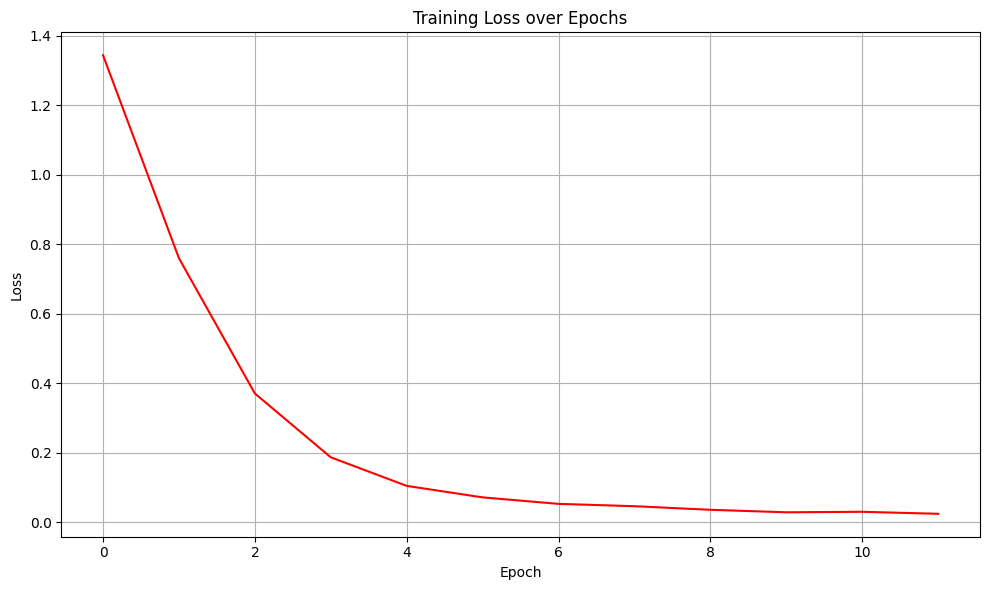

In [18]:
from util import plot_training_loss

plot_training_loss(model.train_epoch_losses)

In [19]:
from util import show_table

show_table(model.validation_epoch_outputs)

,epoch,总样本数,正确样本数,样本准确率,总Token数,正确Token数,Token准确率
0,0,5000,389,0.0778,15714,7880,0.5015
1,1,5000,2203,0.4406,15714,11281,0.7179
2,2,5000,3362,0.6724,15714,13375,0.8512
3,3,5000,4091,0.8182,15714,14542,0.9254
4,4,5000,4353,0.8706,15714,14878,0.9468
5,5,5000,4437,0.8874,15714,15060,0.9584
6,6,5000,4702,0.9404,15714,15339,0.9761
7,7,5000,4541,0.9082,15714,15170,0.9654
8,8,5000,4732,0.9464,15714,15397,0.9798
9,9,5000,4740,0.9480,15714,15399,0.9800


## 使用模型进行预测

In [20]:

from util import print_aigc_results

questions = ["829+33", "58+136", "22+593", "243+269", "1+1"]
answers = ["862", "194", "615", "512", "2"]


# 2. 使用与训练时统一的 transform 方法对文本进行处理
question_encoded = encoder_transform(questions)
encoder_input_ids = question_encoded["input_ids"]


# 3. 使用模型进行预测
generated_texts = model.generate(encoder_input_ids)

# 4. 输出预测结果
print_aigc_results(questions, answers, generated_texts)


🎯 生成结果 (准确率: 5/5 = 100.00%)：
+---------+--------+--------+------+
|   输入  | 真实值 | 预测值 | 标记 |
+---------+--------+--------+------+
|  829+33 |  862   |  862   |  ☑   |
|  58+136 |  194   |  194   |  ☑   |
|  22+593 |  615   |  615   |  ☑   |
| 243+269 |  512   |  512   |  ☑   |
|   1+1   |   2    |   2    |  ☑   |
+---------+--------+--------+------+


## 模型测试

## 拓展阅读

## 存在的问题

思考一下，引出下一章